In [64]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Data Loading and Structure

In [65]:
from src.data_loader import load_wti_data
df = load_wti_data()
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,,
2021-06-01,67.720001,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,68.830002,69.000000,67.779999,67.989998,332995
2021-06-03,68.809998,68.809998,69.400002,68.190002,68.760002,351367
2021-06-04,69.620003,69.620003,69.760002,68.330002,68.910004,326250
2021-06-07,69.230003,69.230003,70.000000,68.930000,69.519997,365621


In [66]:
df.to_csv("../data/raw/wti.csv")

In [67]:
df.columns

MultiIndex([('Adj Close', 'CL=F'),
            (    'Close', 'CL=F'),
            (     'High', 'CL=F'),
            (      'Low', 'CL=F'),
            (     'Open', 'CL=F'),
            (   'Volume', 'CL=F')],
           names=['Price', 'Ticker'])

In [68]:
#1. Flatten the multi-level columns
df.columns = df.columns.get_level_values(0)
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-06-01,67.720001,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,68.830002,69.000000,67.779999,67.989998,332995
2021-06-03,68.809998,68.809998,69.400002,68.190002,68.760002,351367
2021-06-04,69.620003,69.620003,69.760002,68.330002,68.910004,326250
2021-06-07,69.230003,69.230003,70.000000,68.930000,69.519997,365621


In [69]:
#2. Remove Adjusted Close
df.drop(columns=['Adj Close'], inplace=True)
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-06-01,67.720001,68.870003,66.410004,66.680000,570985
2021-06-02,68.830002,69.000000,67.779999,67.989998,332995
2021-06-03,68.809998,69.400002,68.190002,68.760002,351367
2021-06-04,69.620003,69.760002,68.330002,68.910004,326250
2021-06-07,69.230003,70.000000,68.930000,69.519997,365621


In [70]:
df.to_csv("../data/processed/wti_clean.csv")

In [71]:
df.index

DatetimeIndex(['2021-06-01', '2021-06-02', '2021-06-03', '2021-06-04',
               '2021-06-07', '2021-06-08', '2021-06-09', '2021-06-10',
               '2021-06-11', '2021-06-14',
               ...
               '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20',
               '2026-05-21', '2026-05-22', '2026-05-26', '2026-05-27',
               '2026-05-28', '2026-05-29'],
              dtype='datetime64[s]', name='Date', length=1257, freq=None)

DateTime is already set as index.

In [72]:
#3. Check shape of the DataFrame
df.shape

(1257, 5)

In [73]:
#4. Check information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1257 entries, 2021-06-01 to 2026-05-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1257 non-null   float64
 1   High    1257 non-null   float64
 2   Low     1257 non-null   float64
 3   Open    1257 non-null   float64
 4   Volume  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


# Data Quality Assessment

In [74]:
#5. Check for missing values
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [75]:
#6. Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [76]:
#7. Check duplicate Datetime index
df.index.duplicated().sum() 

np.int64(0)

In [77]:
#8. Datetime index range
print(f"Start date: {df.index.min()}")
print(f"End date: {df.index.max()}")

Start date: 2021-06-01 00:00:00
End date: 2026-05-29 00:00:00


# Descriptive Statistics

In [78]:
#9. Summary statistics
df.describe()

Price,Close,High,Low,Open,Volume
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,77.933127,79.409101,76.459387,77.989960,3.207643e+05
std,13.083954,13.712635,12.459194,13.121130,1.269177e+05
min,55.270000,56.700001,54.980000,55.230000,0.000000e+00
25%,69.209999,70.269997,68.050003,69.269997,2.594460e+05
50%,75.720001,77.160004,74.309998,75.760002,3.175860e+05
75%,83.629997,85.300003,82.389999,83.690002,3.781460e+05
max,123.699997,130.500000,120.790001,124.660004,1.107193e+06


# Data Validation

In [79]:
#10. OHLC logical checks
(df['High'] < df['Low']).sum()

np.int64(0)

In [80]:
(df["High"] < df["Close"]).sum()

np.int64(0)

In [81]:
(df["Low"] > df["Close"]).sum()

np.int64(0)

# Distribution Analysis

<Axes: >

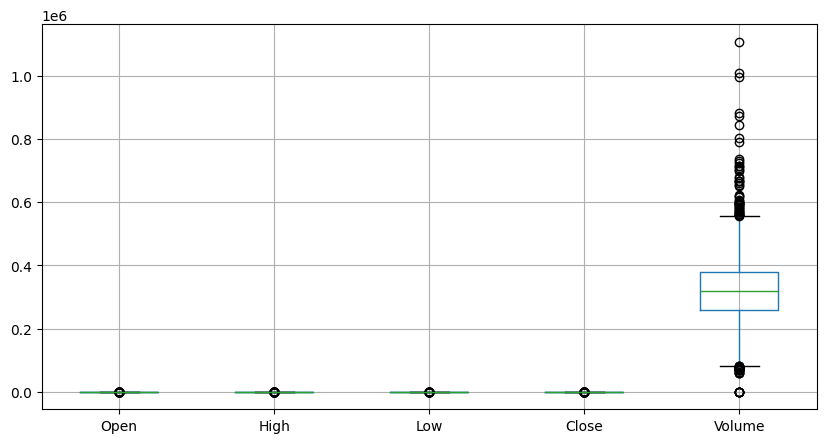

In [82]:
#11. Check for outliers using boxplots
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[cols].boxplot(figsize=(10, 5))

<Axes: >

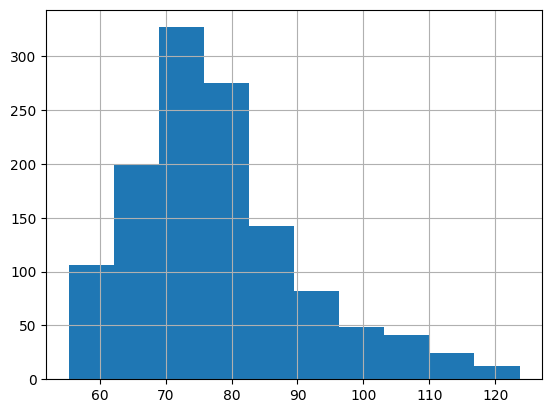

In [83]:
#12. Check distribution of the 'Close' price
df['Close'].hist()

# Time Continuity Check

In [84]:
#13. Regularity of Time Series
df.index.to_series().diff().value_counts()

Date
1 days    983
3 days    226
4 days     34
2 days     13
Name: count, dtype: int64